# Storm Surge in CLIMADA
This notebook looks at the storm surge module `TCSurgeBathtub` in CLIMADA petals. Note that you need to install CLIMADA *and* CLIMADA petals in order to run this code. Instructions on how to install both are [here](https://climada-python.readthedocs.io/en/stable/guide/install.html).

In [2]:
from climada.hazard import TCTracks, TropCyclone, Centroids
from climada_petals.hazard import TCSurgeBathtub
from climada.util.constants import DEMO_DIR

/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/dask/dataframe/_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 12.0.1. Please consider upgrading.
  warnings.warn(


2025-03-20 16:49:20,562 - climada.hazard.tc_tracks - WARNING - The cached IBTrACS data set dates from 2023-06-07 23:07:38 (older than 180 days). Very likely, a more recent version is available. Consider manually removing the file /Users/melissarenard/climada/data/IBTrACS.ALL.v04r00.nc and re-running this function, which will download the most recent version of the IBTrACS data set from the official URL.


/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/climada/hazard/tc_tracks.py:614: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ibtracs_ds.dims['storm'] == 0:
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/climada/hazard/tc_tracks.py:1511: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "_one_interp_data" failed type inference due to: non-precise type pyobject
During: typing of argument at /Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/clim

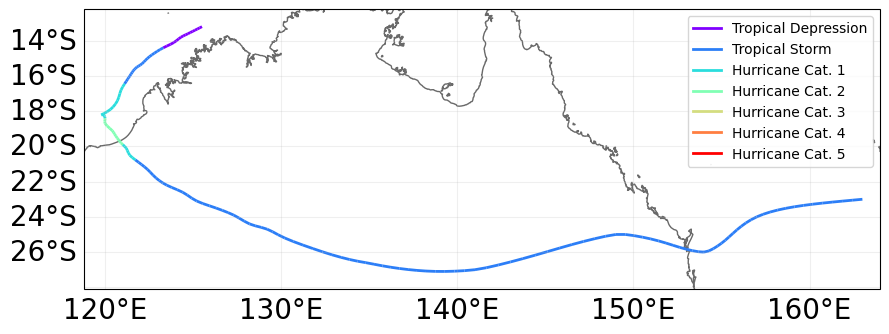

In [3]:
sid = '1995348S15135'
my_tr = TCTracks.from_ibtracs_netcdf(storm_id = sid)
my_tr.equal_timestep(land_params=True)
my_tr.plot();

In [ ]:
min_lat, max_lat, min_lon, max_lon = -22, -14, 119, 125
cent_bang = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res = 0.03)

tc_bang = TropCyclone.from_tracks(my_tr, centroids = cent_bang)

In [25]:
topo_path = DEMO_DIR.joinpath('SRTM15+V2.0_sample.tiff')
ts_bang = TCSurgeBathtub.from_tc_winds(tc_bang, topo_path)

/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


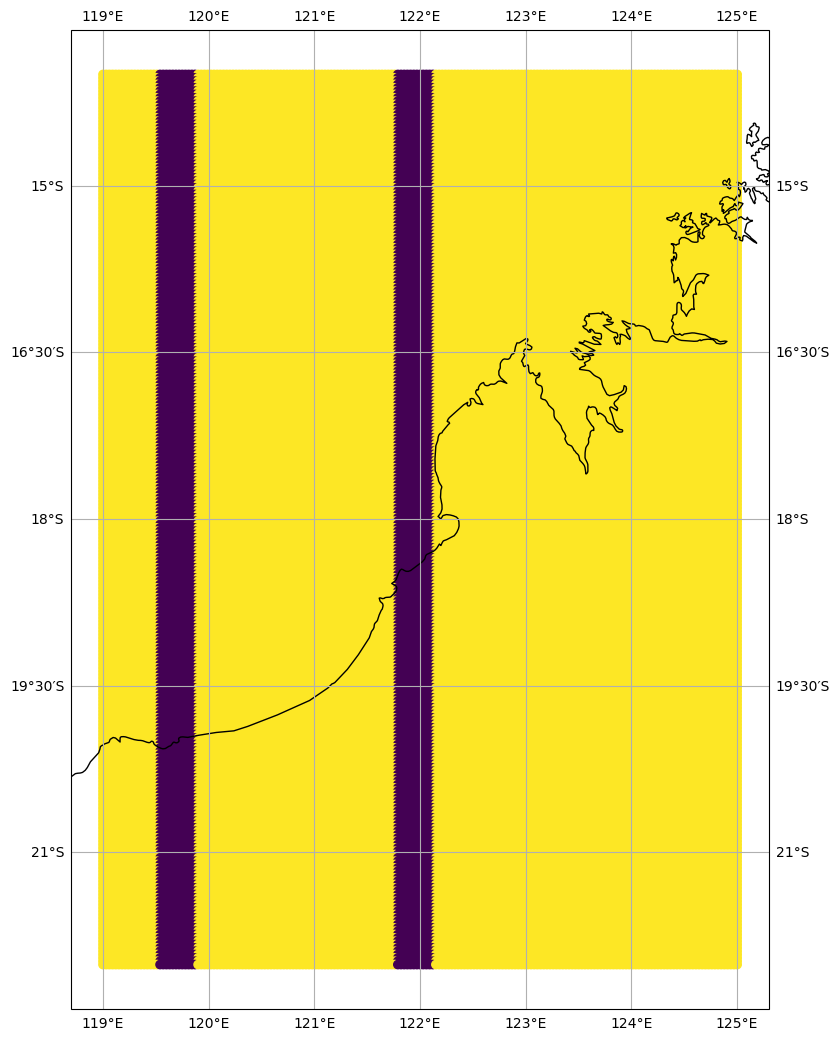

In [26]:
elevation = ts_bang.centroids.get_elevation(topo_path)
ts_bang.centroids.plot(c=elevation, vmin=0, vmax=10);

/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


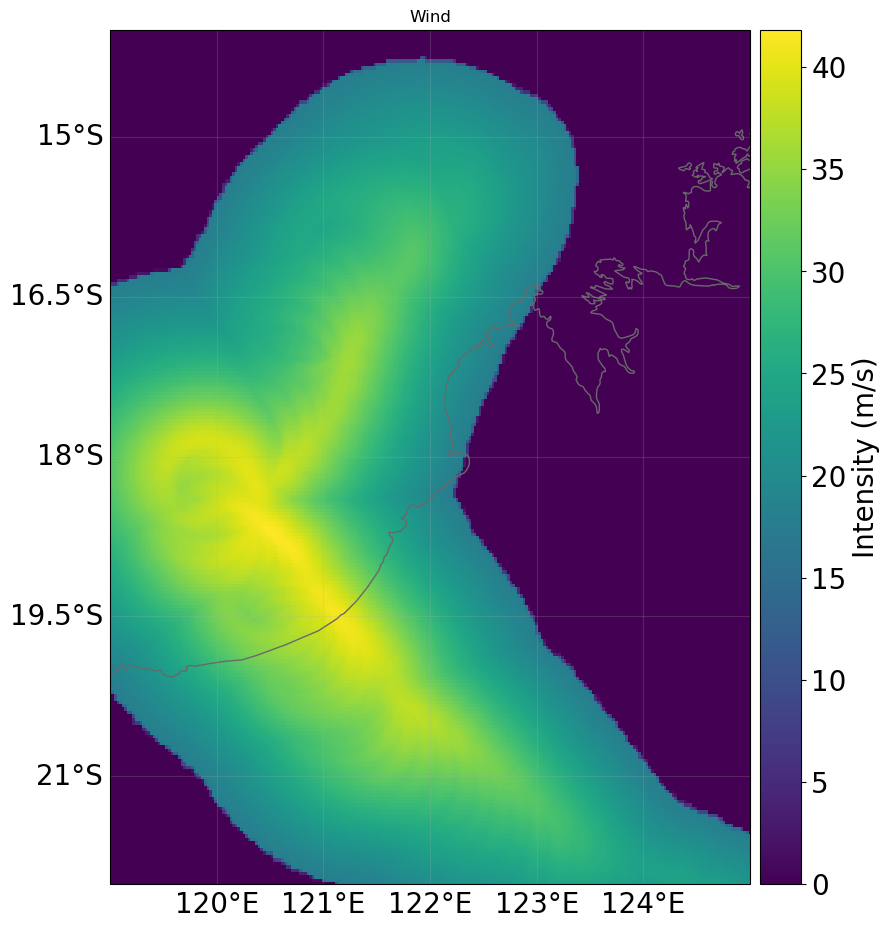

/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/melissarenard/miniforge3/envs/climada_env/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


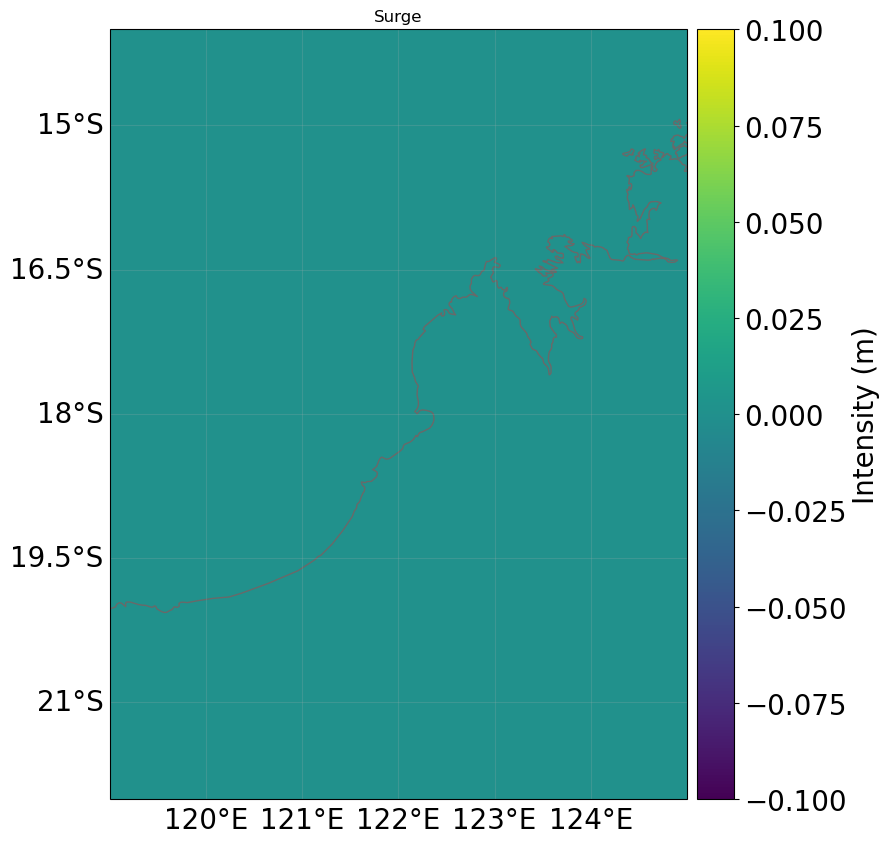

In [27]:
ax = tc_bang.plot_intensity(1)
ax.set_title('Wind')
ax = ts_bang.plot_intensity(1)
ax.set_title('Surge');